In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os 
import glob

In [154]:
class Test:
    def __init__(self, df):
        self.df = df
        self.id = df['participant_ID'][0]
        self.date = df['visit_date'][0]
        self.name = f"{self.id}_{self.date}"
        self.df['Stage'] = self.df[self.df['Phase'] == 'EXERCISE'].groupby(['Speed','Grade']).ngroup() + 1
        #max_stage = self.df['Stage'].max()
        #self.df.loc[self.df['Phase'] == 'WARMUP', 'Stage'] = 0
        #self.df.loc[self.df['Phase'] == 'RECOVERY', 'Stage'] = max_stage + 1
        self.lactate_df = self.df.dropna(subset='La-')[['La-', 'Phase', 't', 'Speed', 'Grade', 'Stage']] 
        self.lactate_df = self.lactate_df.drop(self.lactate_df[self.lactate_df['La-'] > 20].index)
        self.lactate_df['log_La'] = np.log(self.lactate_df['La-'])
        self.lactate_df['log_Speed'] = np.log(self.lactate_df['Speed'])

    """def lactate_graph(self):
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Reference mode
        axes[0].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o')
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Lactate')
        axes[0].set_title('Lactate vs Time Using Reference ' + self.name)
        axes[0].set_ylim(0, None)
        LT1_ref, LT2_ref, LT1_idx_ref, LT2_idx_ref = self.lt_ref_vals()
        if LT1_ref:
            axes[0].axvline(x=LT1_ref, color='r', label='LT1')
        if LT2_ref:
            axes[0].axvline(x=LT2_ref, color='g', linestyle='--', label='LT2')
        ax2_ref = axes[0].twinx()
        axes[0].legend()
        
        # Absolute mode
        axes[1].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o')
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('Lactate')
        axes[1].set_title('Lactate vs Time Using Absolute ' + self.name)
        axes[1].set_ylim(0, None)
        LT1_abs, LT2_abs, LT1_idx_abs, LT2_idx_abs = self.lt_abs_vals()
        axes[1].axhline(y=2, color='r', label='Threshold 2 mmol/L')
        axes[1].axhline(y=4, color='g', linestyle='--', label='Threshold 4 mmol/L')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Extract and return LT1 and LT2 data
        results = {
        'LT1_Lactate_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'La-'] if LT1_ref else None,
        'LT1_Speed_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Speed'] if LT1_ref else None,
        'LT1_Grade_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Grade'] if LT1_ref else None,
        'LT2_Lactate_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'La-'] if LT2_ref else None,
        'LT2_Speed_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Speed'] if LT2_ref else None,
        'LT2_Grade_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Grade'] if LT2_ref else None,
        'LT1_Lactate_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'La-'] if LT1_abs else None,
        'LT1_Speed_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Speed'] if LT1_abs else None,
        'LT1_Grade_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Grade'] if LT1_abs else None,
        'LT2_Lactate_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'La-'] if LT2_abs else None,
        'LT2_Speed_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Speed'] if LT2_abs else None,
        'LT2_Grade_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Grade'] if LT2_abs else None
        }
        return results"""
    def lactate_graph(self):
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        
        # Reference mode
        axes[0].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        axes[0].set_xlabel('Time')
        axes[0].set_ylabel('Lactate mmol/L')
        axes[0].set_title('Lactate vs Time Using Reference ' + self.name)
        axes[0].set_ylim(0, None)
        LT1_ref, LT2_ref, LT1_idx_ref, LT2_idx_ref = self.lt_ref_vals()
        if LT1_ref:
            axes[0].axvline(x=LT1_ref, color='r', label='LT1')
        if LT2_ref:
            axes[0].axvline(x=LT2_ref, color='g', linestyle='--', label='LT2')
        '''
        # Create a twin axis for speed using df's speed data
        ax2_ref = axes[0].twinx()
        
        # Plot speed from df on the twin axis using lactate_df's times as the x-axis
        ax2_ref.plot(self.lactate_df['t'], self.df.loc[self.df['t'].isin(self.lactate_df['t']), 'Speed'], color='black', label='Speed', alpha=0.2)
        ax2_ref.set_ylabel('Speed mph', color='black', alpha=0.5)
        ax2_ref.tick_params(axis='y', labelcolor='black')
        '''
        # Reduce the number of x-ticks to only those where lactate measurements exist
        axes[0].set_xticks(self.lactate_df['t'])  # Set ticks only where lactate is measured
        
        axes[0].legend(loc='upper left')
        #ax2_ref.legend(loc='upper right')
        
        # Absolute mode
        axes[1].plot(self.lactate_df['t'], self.lactate_df['La-'], marker='o', label='Lactate')
        axes[1].set_xlabel('Time')
        axes[1].set_ylabel('Lactate mmol/L')
        axes[1].set_title('Lactate vs Time Using Absolute ' + self.name)
        axes[1].set_ylim(0, None)
        LT1_abs, LT2_abs, LT1_idx_abs, LT2_idx_abs = self.lt_abs_vals()
        axes[1].axhline(y=2, color='r', label='Threshold 2 mmol/L')
        axes[1].axhline(y=4, color='g', linestyle='--', label='Threshold 4 mmol/L')
        '''
        # Create a twin axis for speed
        ax2_abs = axes[1].twinx()
        
        # Plot speed from df on the twin axis using lactate_df's times as the x-axis
        ax2_abs.plot(self.lactate_df['t'], self.df.loc[self.df['t'].isin(self.lactate_df['t']), 'Speed'], color='black', label='Speed', alpha=0.2)
        ax2_abs.set_ylabel('Speed mph', color='black', alpha=0.5)
        ax2_abs.tick_params(axis='y', labelcolor='black')
        '''
        # Reduce the number of x-ticks to only those where lactate measurements exist
        axes[1].set_xticks(self.lactate_df['t'])  # Set ticks only where lactate is measured
        
        axes[1].legend(loc='upper left')
        #ax2_abs.legend(loc='upper right')
        
        plt.tight_layout()
        plt.show()
        
        # Extract and return LT1 and LT2 data
        results = {
        'LT1_Lactate_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'La-'] if LT1_ref else None,
        'LT1_Speed_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Speed'] if LT1_ref else None,
        'LT1_Grade_Ref': self.lactate_df.loc[LT1_idx_ref.idxmax(), 'Grade'] if LT1_ref else None,
        'LT2_Lactate_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'La-'] if LT2_ref else None,
        'LT2_Speed_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Speed'] if LT2_ref else None,
        'LT2_Grade_Ref': self.lactate_df.loc[LT2_idx_ref.idxmax(), 'Grade'] if LT2_ref else None,
        'LT1_Lactate_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'La-'] if LT1_abs else None,
        'LT1_Speed_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Speed'] if LT1_abs else None,
        'LT1_Grade_Abs': self.lactate_df.loc[LT1_idx_abs.idxmax(), 'Grade'] if LT1_abs else None,
        'LT2_Lactate_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'La-'] if LT2_abs else None,
        'LT2_Speed_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Speed'] if LT2_abs else None,
        'LT2_Grade_Abs': self.lactate_df.loc[LT2_idx_abs.idxmax(), 'Grade'] if LT2_abs else None
        }
        return results

    
    
    def lt_ref_vals(self):
        lt1ref_index = (self.lactate_df['La-'].diff() >= 0.5)
        lt2ref_index = (self.lactate_df['La-'].diff() >= 1)
        LT1ref = self.lactate_df.loc[lt1ref_index.idxmax(), 't'] if lt1ref_index.any() else None
        LT2ref = self.lactate_df.loc[lt2ref_index.idxmax(), 't'] if lt2ref_index.any() else None
        return LT1ref, LT2ref, lt1ref_index, lt2ref_index
    
    def lt_abs_vals(self):
        lt1ref_index = (self.lactate_df['La-'] >= 2)
        lt2ref_index = (self.lactate_df['La-'] >= 4)
        LT1ref = self.lactate_df.loc[lt1ref_index.idxmax(), 't'] if lt1ref_index.any() else None
        LT2ref = self.lactate_df.loc[lt2ref_index.idxmax(), 't'] if lt2ref_index.any() else None
        return LT1ref, LT2ref, lt1ref_index, lt2ref_index
    
    def linear_regression(self, x, y):
        """Perform linear regression and return slope, intercept, and r-value."""
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        return slope, intercept, r_value
    
    def plot_regression(self, x, y, slope, intercept, xlabel, ylabel, title):
        """Plot the data and regression line."""
        plt.scatter(x, y, color='black', label='Data')
        plt.plot(x, slope * x + intercept, 'r-', label=f'Linear Fit (r={slope:.2f})')
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.title(title)
        plt.legend()
        plt.grid()
        plt.show()
    
    
    def lt1_log(self):
        """Finds LT1 (intersection of log[lactate] vs. log[speed])"""
        log_speed = self.lactate_df['log_Speed']
        log_lactate = self.lactate_df['log_La']

        # Perform linear regression
        slope, intercept, r_value = self.linear_regression(log_speed, log_lactate)
        
        # Plot the results
        self.plot_regression(log_speed, log_lactate, slope, intercept, 'log(Speed)', 'log(Lactate)', 'log(Lactate) vs. log(Speed) Regression')

        # Calculate and return LT1
        LT1 = np.exp(intercept)  # Convert back to original speed scale
        return LT1

    def lt2_semilog(self):
        """Finds LT2 (intersection of log[lactate] vs. speed)"""
        speed = self.lactate_df['Speed']
        log_lactate = self.lactate_df['log_La']

        # Perform linear regression
        slope, intercept, r_value = self.linear_regression(speed, log_lactate)
        
        # Plot the results
        self.plot_regression(speed, log_lactate, slope, intercept, 'Speed', 'log(Lactate)', 'log(Lactate) vs. Speed Regression')

        # Calculate and return LT2
        LT2 = intercept  # This is the speed at which log(Lactate) = 0
        return LT2

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


NameError: name 'ax2_abs' is not defined

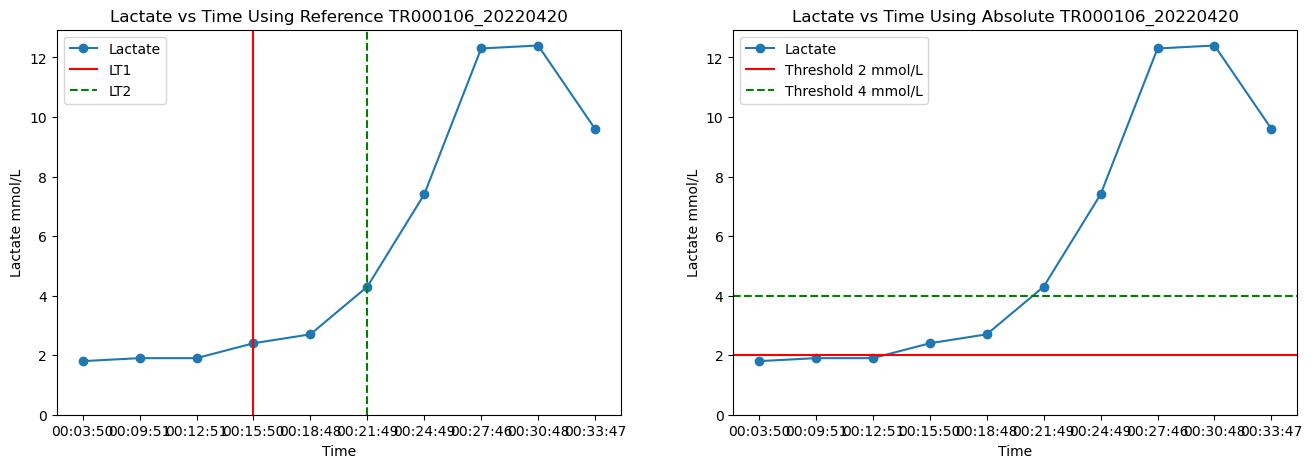

In [156]:
df = pd.read_csv('visit_data/TR000106_20220420_visit_data.csv')
test = Test(df)
test.lactate_graph()

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


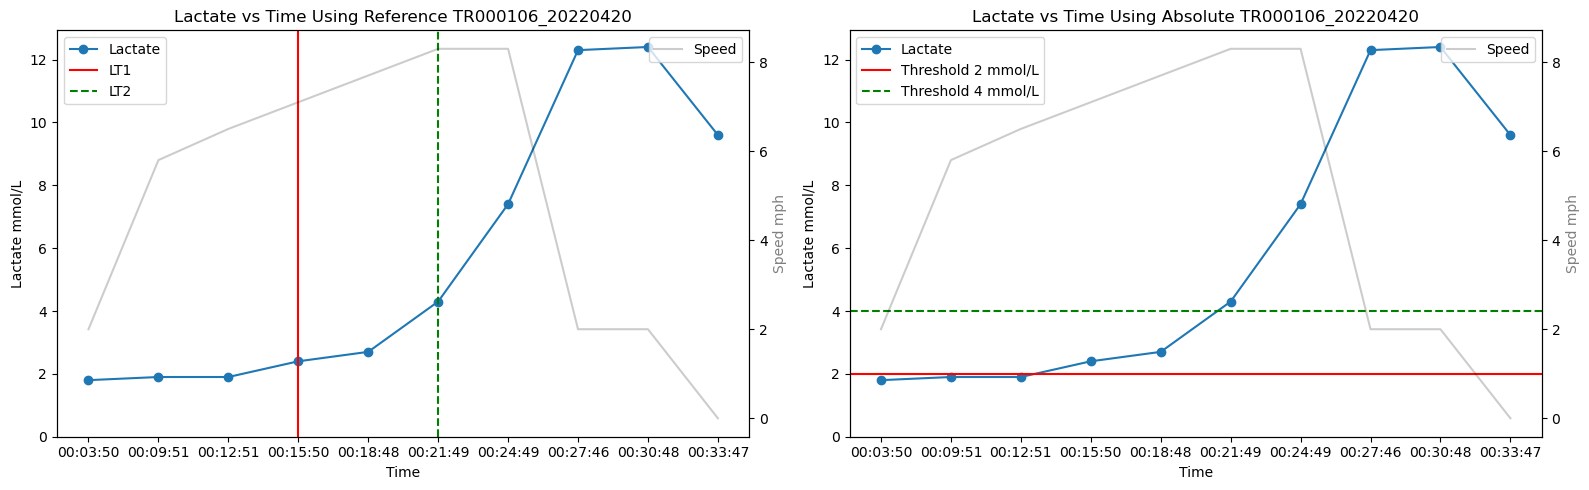

'TR000106_20220420'

In [152]:
df = pd.read_csv('visit_data/TR000106_20220420_visit_data.csv')
test = Test(df)
test.lactate_graph()
test.name

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


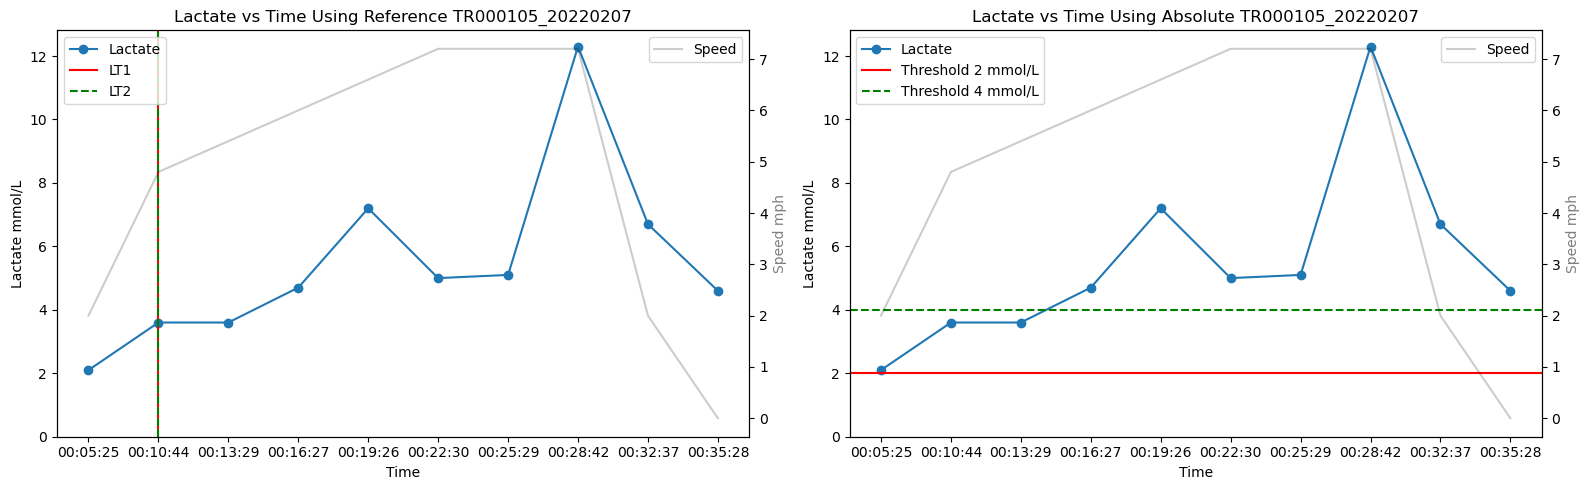

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


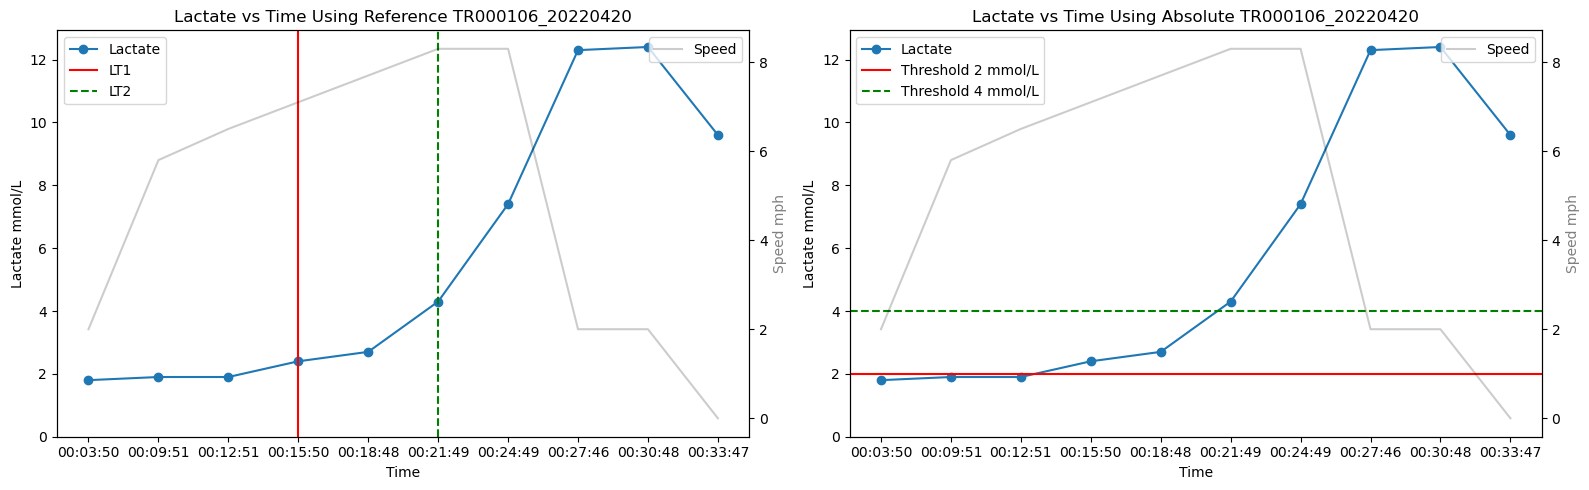

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


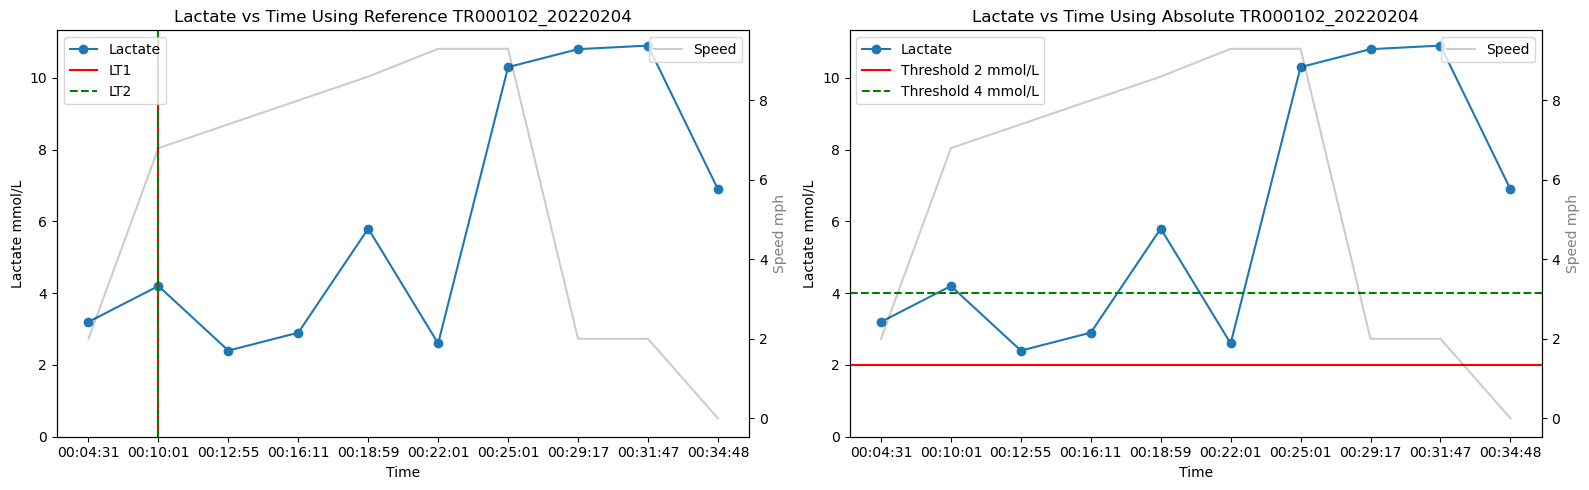

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


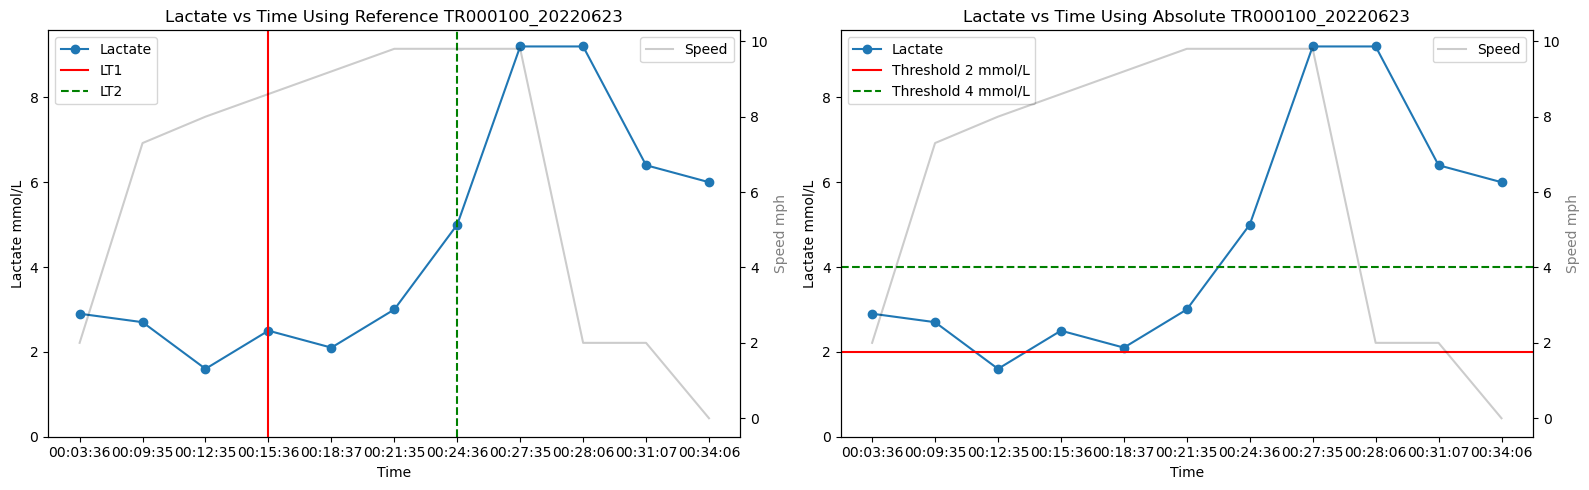

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


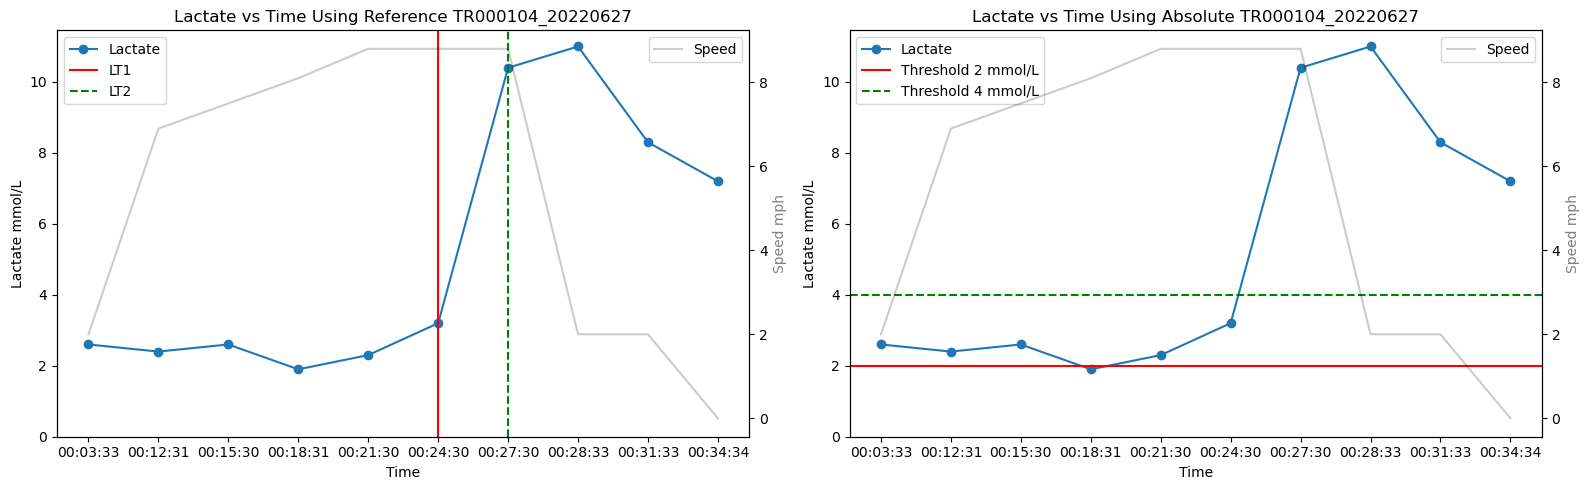

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


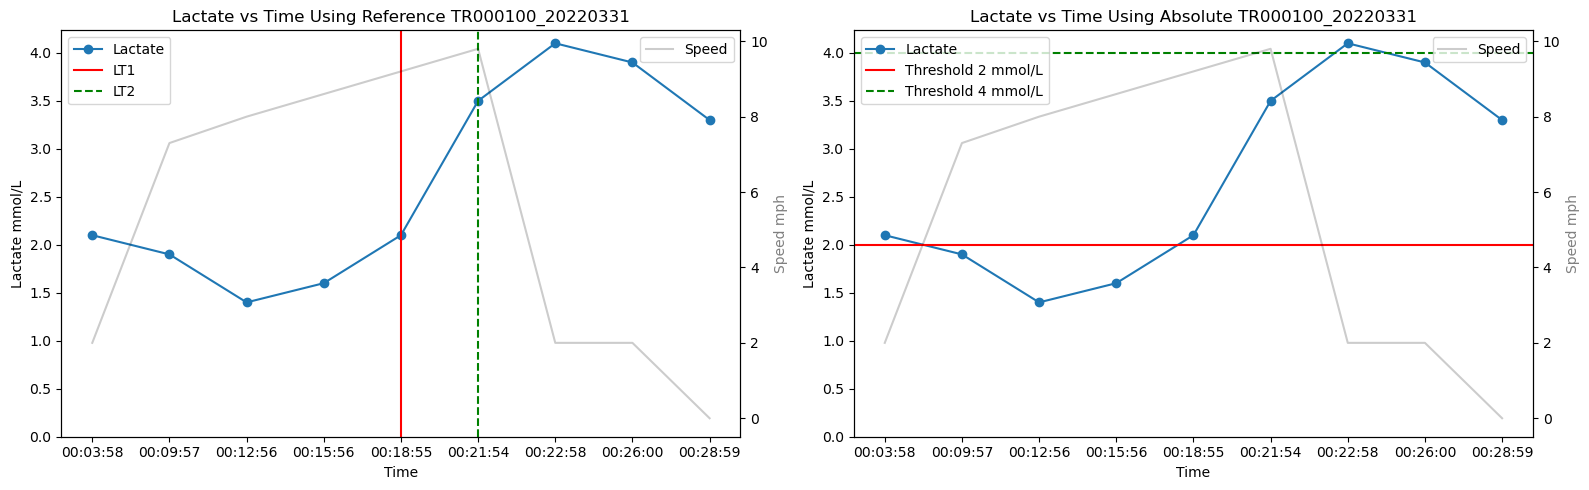

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


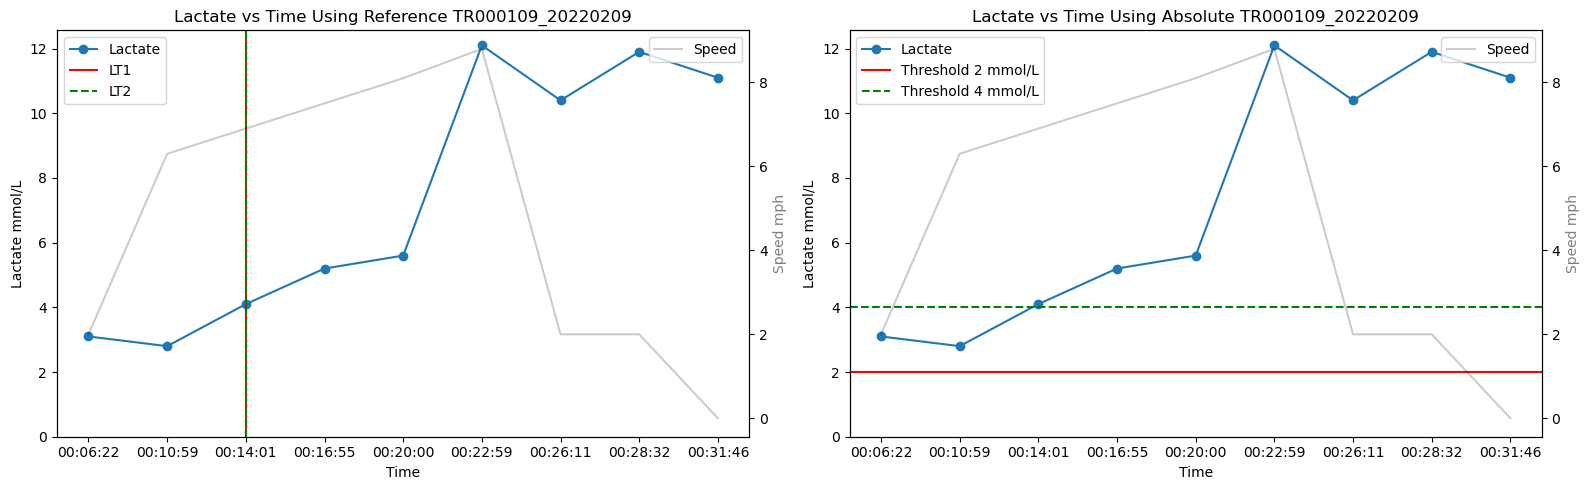

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


ValueError: x and y must have same first dimension, but have shapes (11,) and (13,)

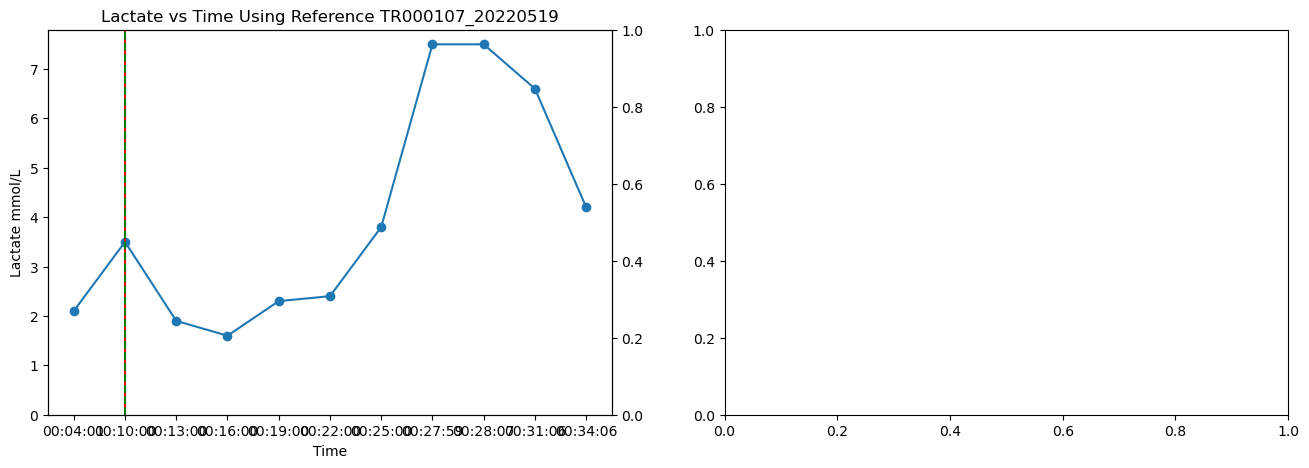

In [153]:
path = r'visit_data'
filenames = glob.glob(os.path.join(path, "*.csv"))

results = []

for filename in filenames:
    df = pd.read_csv(filename)
    test = Test(df)
    test_name = test.name  # Assuming each test has a unique name

    test_results = test.lactate_graph()  # Get structured results
    test_results['Test Name'] = test_name  # Add test name for indexing
    results.append(test_results)

# Convert results into a DataFrame
results_df = pd.DataFrame(results).set_index('Test Name')

results_df